# Does tyre strategy correlate with winning in Formula 1?

**Data Science Toolbox, Formative Sprint 0, sport domain: Formula 1 (FastF1)**

## 1. Question and approach

Teams can choose between three dry tyre compounds each weekend: **Soft**, **Medium** and **Hard**. In a dry race each driver must use at least two different dry compounds. This notebook asks:

> *Is there a relationship between a driver's tyre make-up in a race (starting compound, number of stops, share of laps on each compound) and whether they win?*

**Data.** We use the [FastF1](https://docs.fastf1.dev/) Python package. It provides lap-by-lap timing data from the official F1 live-timing feed. Each lap row carries `Compound`, `Stint`, `TyreLife` and `FreshTyre`, and `session.results` gives grid and finishing positions.

**Starting point.** The data handling is adapted from the official FastF1 gallery example [*Tyre strategies during a race*](https://docs.fastf1.dev/gen_modules/examples_gallery/plot_strategy.html). That example groups laps by `Driver`, `Stint` and `Compound` to get stint lengths for a single race. We extend it in three ways:
1. run it over every race in several seasons, not just one,
2. turn each driver's race into a row of strategy features, and
3. test those features against race outcome.

**The key difficulty is confounding.** Fast cars start at the front *and* win, and they may also choose different tyres. So a raw correlation between tyres and winning could just be a correlation between car speed and winning. We therefore build up from raw comparisons to models that control for grid position and compare drivers only *within the same race*.

**Season.** We analyse the **2022 season** only (22 races). We stop at one season to stay within the F1 data servers' rate limits. 2022 is also a natural choice: it was the first year of the current ground-effect cars and 18-inch tyres, and the first year without the rule forcing top-ten qualifiers to start on their Q2 tyre, so starting compound was a free choice for everyone. Running more seasons only needs one more entry in `SEASONS`, but spread the downloads over several sessions. *(In the run shown here, the saved data file also contained races from an earlier download, giving 38 races in total. See the note at the end of Section 6.)*

## 2. Setup

Install requirements once (uncomment the line below if needed). The first data download takes a while: FastF1 pulls each race from the F1 servers and caches it to `fastf1_cache/`, so reruns are fast.

In [1]:
# %pip install fastf1 statsmodels scipy matplotlib pandas
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.discrete.conditional_models import ConditionalLogit
import fastf1

warnings.filterwarnings("ignore")
fastf1.set_log_level("ERROR")

CACHE_DIR = "fastf1_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

SEASONS = [2022]   # one season keeps us under FastF1's API rate limits
DATA_FILE = "race_strategies.csv"   # per-driver-per-race table, built in Section 3
RNG = np.random.default_rng(2026)

DRY = ["SOFT", "MEDIUM", "HARD"]
COMPOUND_COLOURS = {"SOFT": "#da291c", "MEDIUM": "#ffd12e", "HARD": "#b0b0b0",
                    "INTERMEDIATE": "#43b02a", "WET": "#0067ad", "UNKNOWN": "#555555"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("FastF1 version:", fastf1.__version__)

FastF1 version: 3.8.3


## 3. Data: from laps to one row per driver per race

This is the official gallery example run on a single race (2022 Hungarian GP, the same race the official example uses). We changed it in two ways: it uses our own compound colours, and the race winner is marked with ★. Looking at one race before scaling up shows what a "strategy" is in the data: a sequence of stints, each on one compound.

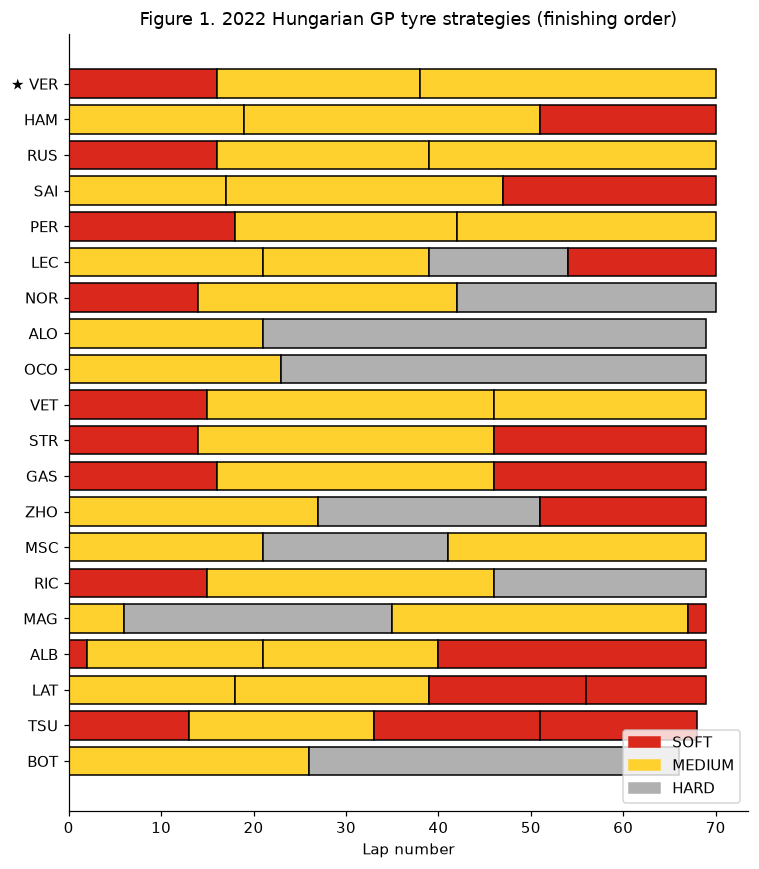

In [2]:
example = fastf1.get_session(2022, "Hungary", "R")
example.load(laps=True, telemetry=False, weather=False, messages=False)

stints = (example.laps[["Driver", "Stint", "Compound", "LapNumber"]]
          .groupby(["Driver", "Stint", "Compound"]).count().reset_index()
          .rename(columns={"LapNumber": "StintLength"}))

order = example.results.sort_values("Position")["Abbreviation"].tolist()
winner = order[0]

fig, ax = plt.subplots(figsize=(7, 8))
for i, drv in enumerate(order):
    prev_end = 0
    for _, row in stints[stints["Driver"] == drv].iterrows():
        ax.barh(i, row["StintLength"], left=prev_end, edgecolor="black",
                color=COMPOUND_COLOURS.get(row["Compound"], "#555555"))
        prev_end += row["StintLength"]
ax.set_yticks(range(len(order)), [f"★ {d}" if d == winner else d for d in order])
ax.invert_yaxis()
ax.set_xlabel("Lap number")
ax.set_title("Figure 1. 2022 Hungarian GP tyre strategies (finishing order)")
handles = [plt.Rectangle((0, 0), 1, 1, color=COMPOUND_COLOURS[c]) for c in DRY]
ax.legend(handles, DRY, loc="lower right")
plt.tight_layout(); plt.show()

Next we turn every driver's race into one row of features:

| Feature | Meaning |
|---|---|
| `StartCompound` | compound used on the first stint |
| `NStops` | number of stints − 1 (pit stops for tyres) |
| `Sequence` | e.g. `M-H` = Medium then Hard |
| `share_SOFT/MEDIUM/HARD` | fraction of the driver's laps on each compound |
| `Grid`, `Position`, `Won`, `Podium` | outcome and the main confounder |
| `WetRace` | anyone used Intermediate/Wet tyres in that race |

Rows are written to `race_strategies.csv` after each race. If the download stops partway (the F1 servers are rate-limited), just rerun the cell and it will carry on from where it stopped.

In [3]:
def race_strategies(year, rnd):
    # Return one row per driver for a single race.
    session = fastf1.get_session(year, rnd, "R")
    session.load(laps=True, telemetry=False, weather=False, messages=False)
    laps = session.laps.copy()
    laps["Compound"] = laps["Compound"].fillna("UNKNOWN").replace(
        {"": "UNKNOWN", "TEST_UNKNOWN": "UNKNOWN", "nan": "UNKNOWN"})
    res = session.results
    wet_race = bool(laps["Compound"].isin(["INTERMEDIATE", "WET"]).any())
    n_cars = len(res)

    rows = []
    for _, r in res.iterrows():
        drv_laps = laps[laps["Driver"] == r["Abbreviation"]]
        if drv_laps.empty:
            continue
        per_stint = (drv_laps.dropna(subset=["Stint"])
                     .groupby("Stint")["Compound"]
                     .agg(lambda s: s.mode().iat[0]))
        seq = per_stint.tolist()
        share = drv_laps["Compound"].value_counts(normalize=True)
        grid = r["GridPosition"]
        rows.append({
            "Year": year, "Round": rnd, "RaceID": f"{year}-{rnd:02d}",
            "Event": session.event["EventName"],
            "Driver": r["Abbreviation"], "Team": r["TeamName"],
            "Grid": n_cars if (pd.isna(grid) or grid == 0) else grid,  # 0 = pit-lane start
            "Position": r["Position"],
            "Classified": str(r["ClassifiedPosition"]).isnumeric(),
            "Won": int(r["Position"] == 1),
            "Podium": int(r["Position"] <= 3),
            "Points": r["Points"],
            "LapsDone": len(drv_laps),
            "NStints": len(seq),
            "NStops": max(len(seq) - 1, 0),
            "StartCompound": seq[0] if seq else "UNKNOWN",
            "Sequence": "-".join(c[0] for c in seq),
            "WetRace": wet_race,
            **{f"share_{c}": float(share.get(c, 0.0))
               for c in DRY + ["INTERMEDIATE", "WET", "UNKNOWN"]},
        })
    return pd.DataFrame(rows)


def collect(seasons, data_file=DATA_FILE):
    done = pd.read_csv(data_file) if os.path.exists(data_file) else pd.DataFrame()
    done_ids = set(done["RaceID"]) if not done.empty else set()
    failures = []
    for year in seasons:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        schedule = schedule[schedule["EventDate"] < pd.Timestamp.now()]
        for rnd, name in zip(schedule["RoundNumber"], schedule["EventName"]):
            race_id = f"{year}-{rnd:02d}"
            if race_id in done_ids:
                continue
            try:
                df_race = race_strategies(year, int(rnd))
                df_race.to_csv(data_file, mode="a", index=False,
                               header=not os.path.exists(data_file))
                print(f"✓ {race_id} {name}: {len(df_race)} drivers")
            except Exception as e:   # missing data, rate limit, network...
                failures.append((race_id, name, repr(e)[:80]))
                print(f"✗ {race_id} {name}: {repr(e)[:80]}")
    if failures:
        print(f"\n{len(failures)} races failed; rerun this cell to retry them.")
    return pd.read_csv(data_file)


df = collect(SEASONS)
print(df.shape)
df.head()

✓ 2022-01 Bahrain Grand Prix: 20 drivers
✓ 2022-02 Saudi Arabian Grand Prix: 18 drivers
✓ 2022-03 Australian Grand Prix: 20 drivers
✓ 2022-04 Emilia Romagna Grand Prix: 20 drivers
✓ 2022-05 Miami Grand Prix: 20 drivers
✓ 2022-06 Spanish Grand Prix: 20 drivers
✓ 2022-07 Monaco Grand Prix: 20 drivers
✓ 2022-08 Azerbaijan Grand Prix: 20 drivers
✓ 2022-09 Canadian Grand Prix: 20 drivers
✓ 2022-10 British Grand Prix: 20 drivers
✓ 2022-11 Austrian Grand Prix: 20 drivers
✓ 2022-12 French Grand Prix: 20 drivers
✓ 2022-13 Hungarian Grand Prix: 20 drivers
✓ 2022-14 Belgian Grand Prix: 20 drivers
✓ 2022-15 Dutch Grand Prix: 20 drivers
✓ 2022-16 Italian Grand Prix: 20 drivers
✓ 2022-17 Singapore Grand Prix: 20 drivers
✓ 2022-18 Japanese Grand Prix: 20 drivers
✓ 2022-19 United States Grand Prix: 20 drivers
✓ 2022-20 Mexico City Grand Prix: 20 drivers
✓ 2022-21 São Paulo Grand Prix: 20 drivers
✓ 2022-22 Abu Dhabi Grand Prix: 20 drivers
(438, 24)


,Year,Round,RaceID,Event,Driver,Team,Grid,Position,Classified,Won,...,NStops,StartCompound,Sequence,WetRace,share_SOFT,share_MEDIUM,share_HARD,share_INTERMEDIATE,share_WET,share_UNKNOWN
0,2022,1,2022-01,Bahrain Grand Prix,LEC,Ferrari,1.0,1.0,True,1,...,3,SOFT,S-S-M-S,False,0.736842,0.263158,0.000000,0.0,0.0,0.0
1,2022,1,2022-01,Bahrain Grand Prix,SAI,Ferrari,3.0,2.0,True,0,...,3,SOFT,S-S-M-S,False,0.807018,0.192982,0.000000,0.0,0.0,0.0
2,2022,1,2022-01,Bahrain Grand Prix,HAM,Mercedes,5.0,3.0,True,0,...,3,SOFT,S-H-M-S,False,0.421053,0.298246,0.280702,0.0,0.0,0.0
3,2022,1,2022-01,Bahrain Grand Prix,RUS,Mercedes,9.0,4.0,True,0,...,3,SOFT,S-H-M-S,False,0.473684,0.210526,0.315789,0.0,0.0,0.0
4,2022,1,2022-01,Bahrain Grand Prix,MAG,Haas F1 Team,7.0,5.0,True,0,...,3,SOFT,S-S-M-S,False,0.789474,0.210526,0.000000,0.0,0.0,0.0


### 3.1 Cleaning decisions

* **Dry races only.** Wet races follow different logic (tyre changes are forced by the weather) and the two-compound rule doesn't apply, so we drop any race where anyone ran Intermediates or Wets.
* **Classified finishers only.** A driver who retires on lap 10 has a truncated strategy, so their "one stint" isn't a real choice. Winners are always classified, so comparing winners with other *classified* drivers is a like-for-like comparison. (This is a deliberate survivorship filter; see Limitations.)
* **Drop rows with >10% unknown compound**, where the timing feed lost tyre information.

In [4]:
df["Classified"] = df["Classified"].astype(bool)
df["WetRace"] = df["WetRace"].astype(bool)

n_races_all = df["RaceID"].nunique()
dry = df[(~df["WetRace"]) & df["Classified"] & (df["share_UNKNOWN"] <= 0.10)].copy()
dry = dry[dry["StartCompound"].isin(DRY)]
dry = dry[dry.groupby("RaceID")["Won"].transform("sum") == 1]   # keep races whose winner survived filtering

print(f"Races downloaded: {n_races_all}")
print(f"Wet races removed: {df.loc[df['WetRace'], 'RaceID'].nunique()}")
print(f"Dry races analysed: {dry['RaceID'].nunique()}  |  driver-races: {len(dry)}  |  winners: {dry['Won'].sum()}")
dry[["Grid", "Position", "NStops", "share_SOFT", "share_MEDIUM", "share_HARD"]].describe().round(2)

Races downloaded: 22
Wet races removed: 4
Dry races analysed: 18  |  driver-races: 309  |  winners: 18


,Grid,Position,NStops,share_SOFT,share_MEDIUM,share_HARD
count,309.00,309.00,309.00,309.00,309.00,309.00
mean,10.63,9.16,2.00,0.20,0.39,0.40
std,5.88,5.08,0.87,0.25,0.19,0.30
min,1.00,1.00,1.00,0.00,0.00,0.00
25%,5.00,5.00,1.00,0.00,0.27,0.00
50%,11.00,9.00,2.00,0.00,0.35,0.42
75%,16.00,13.00,3.00,0.38,0.55,0.66
max,20.00,20.00,5.00,0.88,0.98,0.98


## 4. Exploratory analysis

### 4.1 Starting compound and number of stops: winners vs the field

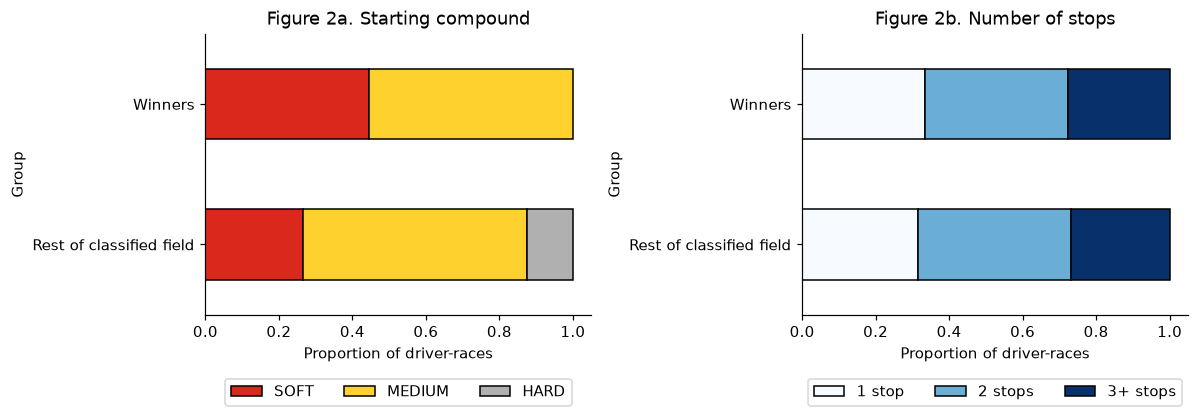

StartCompound,SOFT,MEDIUM,HARD,All
Group,,,,
Rest of classified field,77,178,36,291
Winners,8,10,0,18
All,85,188,36,309


In [5]:
dry["Group"] = np.where(dry["Won"] == 1, "Winners", "Rest of classified field")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

start_tab = pd.crosstab(dry["Group"], dry["StartCompound"], normalize="index")[DRY]
start_tab.plot.barh(stacked=True, ax=axes[0], color=[COMPOUND_COLOURS[c] for c in DRY],
                    edgecolor="black", legend=False)
axes[0].set_xlabel("Proportion of driver-races")
axes[0].set_title("Figure 2a. Starting compound")
axes[0].legend(DRY, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2))

stops_tab = pd.crosstab(dry["Group"], dry["NStops"].clip(upper=3), normalize="index")
stops_tab.columns = [f"{c}{'+' if c == 3 else ''} stop{'s' if c != 1 else ''}" for c in stops_tab.columns]
stops_tab.plot.barh(stacked=True, ax=axes[1], colormap="Blues", edgecolor="black", legend=False)
axes[1].set_xlabel("Proportion of driver-races")
axes[1].set_title("Figure 2b. Number of stops")
axes[1].legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2))
plt.tight_layout(); plt.show()

display(pd.crosstab(dry["Group"], dry["StartCompound"], margins=True)[DRY + ["All"]])

### 4.2 Most common strategies

`Sequence` collapses each driver's race into a string such as `M-H` (Medium then Hard). Figure 3 compares how often each sequence is used by winners and by everyone else.

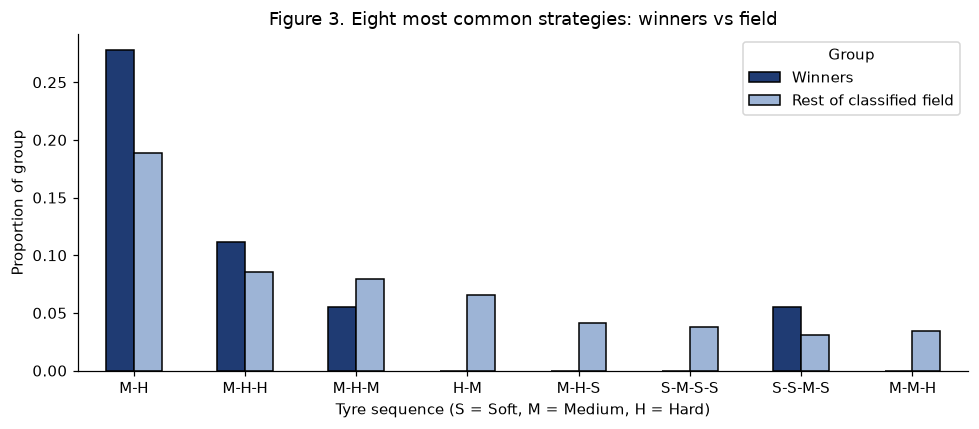

In [6]:
top_seq = dry["Sequence"].value_counts().head(8).index
seq_tab = (pd.crosstab(dry["Sequence"], dry["Group"], normalize="columns")
           .loc[top_seq, ["Winners", "Rest of classified field"]])

ax = seq_tab.plot.bar(figsize=(9, 4), color=["#1f3b73", "#9db4d6"], edgecolor="black")
ax.set_ylabel("Proportion of group")
ax.set_xlabel("Tyre sequence (S = Soft, M = Medium, H = Hard)")
ax.set_title("Figure 3. Eight most common strategies: winners vs field")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 4.3 Compound mix across the finishing order

If tyre make-up mattered, we'd expect the share of laps on a compound to drift with finishing position. Figure 4 shows the mean share of laps on each compound for each finishing position.

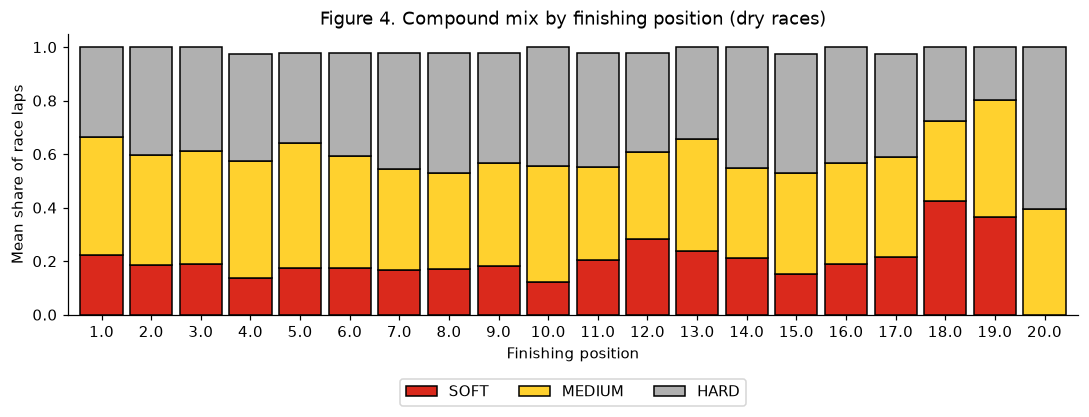

In [7]:
by_pos = (dry[dry["Position"] <= 20].groupby("Position")[[f"share_{c}" for c in DRY]].mean())
ax = by_pos.plot.bar(stacked=True, figsize=(10, 4), width=0.85, edgecolor="black",
                     color=[COMPOUND_COLOURS[c] for c in DRY])
ax.set_ylabel("Mean share of race laps")
ax.set_xlabel("Finishing position")
ax.set_title("Figure 4. Compound mix by finishing position (dry races)")
ax.legend(DRY, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2))
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 4.4 The confounder: grid position

Before testing anything, check how strongly grid position alone predicts the result, and whether tyre choice differs by grid position. If front-runners systematically start on a particular compound, any raw tyre–win correlation is partly a car-speed correlation.

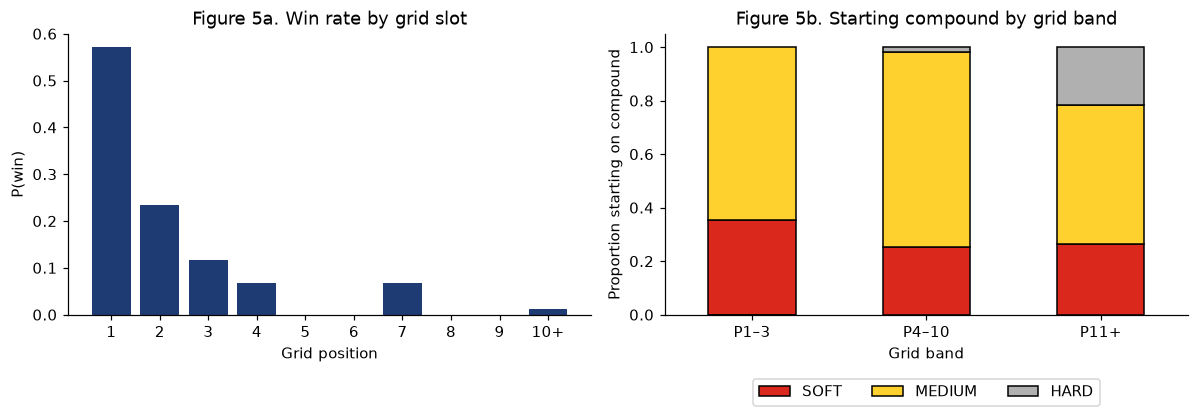

Spearman ρ(grid, finish) = 0.69 (p = 1.6e-45)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

win_by_grid = dry.groupby(dry["Grid"].clip(upper=10))["Won"].mean()
axes[0].bar(win_by_grid.index, win_by_grid.values, color="#1f3b73")
axes[0].set_xticks(range(1, 11), [str(i) if i < 10 else "10+" for i in range(1, 11)])
axes[0].set_xlabel("Grid position"); axes[0].set_ylabel("P(win)")
axes[0].set_title("Figure 5a. Win rate by grid slot")

grid_band = pd.cut(dry["Grid"], [0, 3, 10, 30], labels=["P1–3", "P4–10", "P11+"])
band_tab = pd.crosstab(grid_band, dry["StartCompound"], normalize="index")[DRY]
band_tab.plot.bar(stacked=True, ax=axes[1], color=[COMPOUND_COLOURS[c] for c in DRY],
                  edgecolor="black", legend=False)
axes[1].set_ylabel("Proportion starting on compound"); axes[1].set_xlabel("Grid band")
axes[1].set_title("Figure 5b. Starting compound by grid band")
axes[1].legend(DRY, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2))
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

rho_grid, p_grid = stats.spearmanr(dry["Grid"], dry["Position"])
print(f"Spearman ρ(grid, finish) = {rho_grid:.2f} (p = {p_grid:.1e})")

## 5. Statistical tests

We use four methods, each controlling for more than the last:

1. **χ² test of independence** (start compound × won). This is the naive pooled test.
2. **Within-race permutation test.** It asks whether winners start on, say, Mediums more often than a randomly chosen driver *from the same race* would. That removes track effects (at some circuits almost everyone starts on Mediums).
3. **Spearman correlations** between compound share and finishing position, computed within each race and then averaged.
4. **Logistic regression without and with grid position**, plus a **conditional logit** with race fixed effects. This is the main model.

### 5.1 χ² test (pooled)

$$\chi^2 = \sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}, \qquad E_{ij} = \frac{(\text{row } i \text{ total})(\text{column } j\text{ total})}{N}$$

Cramér's $V = \sqrt{\chi^2 / (N(\min(r,c)-1))}$ measures effect size on a 0–1 scale.

In [9]:
ct = pd.crosstab(dry["Won"], dry["StartCompound"])[DRY]
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

print("Observed:"); display(ct)
print("Expected under independence:")
display(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))
print(f"χ² = {chi2:.2f}, dof = {dof}, p = {p_chi:.3f}, Cramér's V = {cramers_v:.3f}")
if (expected < 5).any():
    print("Note: some expected counts < 5, so the χ² approximation is shaky; see the permutation test below.")

Observed:


StartCompound,SOFT,MEDIUM,HARD
Won,,,
0,77,178,36
1,8,10,0


Expected under independence:


StartCompound,SOFT,MEDIUM,HARD
Won,,,
0,80.0,177.0,33.9
1,5.0,11.0,2.1


χ² = 4.31, dof = 2, p = 0.116, Cramér's V = 0.118
Note: some expected counts < 5, so the χ² approximation is shaky; see the permutation test below.


### 5.2 Within-race permutation test

Null hypothesis: within each race, the winner's tyre choice looks like that of a driver drawn uniformly at random from the classified field. For each of 10,000 permutations we pick one random "winner" per race and record their starting compound and number of stops. The two-sided p-value is the proportion of permuted statistics at least as far from the null mean as the observed one.

We run the test twice: against the whole field, and against **only drivers who started P1–P3**. The second version is a crude control for car speed, since it compares winners only with other front-runners.

In [10]:
def permutation_test(data, value_fn, n_perm=10_000):
    # value_fn maps each row to a number; the statistic is its mean over the chosen "winners".
    vals = value_fn(data).astype(float).to_numpy()
    race_codes, _ = pd.factorize(data["RaceID"])
    n_races = race_codes.max() + 1
    sizes = np.bincount(race_codes)
    # pad each race's values into a (races x max_field) matrix so we can sample all races at once
    V = np.full((n_races, sizes.max()), np.nan)
    pos = data.groupby(race_codes).cumcount().to_numpy()
    V[race_codes, pos] = vals
    observed = vals[data["Won"].to_numpy() == 1].mean()
    idx = (RNG.random((n_perm, n_races)) * sizes).astype(int)
    perm = V[np.arange(n_races), idx].mean(axis=1)
    p = np.mean(np.abs(perm - perm.mean()) >= abs(observed - perm.mean()))
    return observed, perm.mean(), p

contenders = dry[dry["Grid"] <= 3]
contenders = contenders[contenders.groupby("RaceID")["Won"].transform("sum") == 1]

tests = {
    "Start on SOFT (%)":   lambda d: 100 * (d["StartCompound"] == "SOFT"),
    "Start on MEDIUM (%)": lambda d: 100 * (d["StartCompound"] == "MEDIUM"),
    "Start on HARD (%)":   lambda d: 100 * (d["StartCompound"] == "HARD"),
    "Mean no. of stops":   lambda d: d["NStops"],
    "Mean share on HARD":  lambda d: d["share_HARD"],
}
perm_rows = []
for label, fn in tests.items():
    for pool_name, pool in [("Whole field", dry), ("Grid P1–3 only", contenders)]:
        obs, null_mean, p = permutation_test(pool, fn, n_perm=10_000)
        perm_rows.append({"Statistic": label, "Comparison pool": pool_name,
                          "Winners": round(obs, 2), "Random driver (null)": round(null_mean, 2),
                          "p-value": round(p, 4)})
perm_results = pd.DataFrame(perm_rows)
perm_results["Bonferroni sig. (α=0.05/10)"] = perm_results["p-value"] < 0.005
perm_results

,Statistic,Comparison pool,Winners,Random driver (null),p-value,Bonferroni sig. (α=0.05/10)
0,Start on SOFT (%),Whole field,44.44,26.27,0.0200,False
1,Start on SOFT (%),Grid P1–3 only,35.71,33.29,1.0000,False
2,Start on MEDIUM (%),Whole field,55.56,61.89,0.5873,False
3,Start on MEDIUM (%),Grid P1–3 only,64.29,66.62,1.0000,False
4,Start on HARD (%),Whole field,0.00,12.04,0.1266,False
5,Start on HARD (%),Grid P1–3 only,0.00,0.00,1.0000,False
6,Mean no. of stops,Whole field,2.00,1.99,1.0000,False
7,Mean no. of stops,Grid P1–3 only,2.07,2.12,0.7068,False
8,Mean share on HARD,Whole field,0.34,0.41,0.0670,False
9,Mean share on HARD,Grid P1–3 only,0.38,0.42,0.2340,False


### 5.3 Within-race Spearman correlation

For each race we compute Spearman's ρ between the share of laps on a compound and finishing position (positive ρ means more laps on that compound goes with finishing *further back*). A one-sample t-test across races checks whether the average within-race ρ differs from 0. Doing it per race avoids mixing tracks where everyone runs hard with tracks where everyone runs soft (Simpson's paradox).

In [11]:
def within_race_rho(col):
    rhos = []
    for _, g in dry.groupby("RaceID"):
        if g[col].nunique() > 1:
            rhos.append(stats.spearmanr(g[col], g["Position"])[0])
    rhos = np.array(rhos)
    t, p = stats.ttest_1samp(rhos, 0)
    return len(rhos), rhos.mean(), p

rho_tab = pd.DataFrame(
    [(c, *within_race_rho(f"share_{c}")) for c in DRY] + [("NStops", *within_race_rho("NStops"))],
    columns=["Feature", "Races used", "Mean within-race ρ", "p (t-test vs 0)"]).round(3)
rho_tab

,Feature,Races used,Mean within-race ρ,p (t-test vs 0)
0,SOFT,14,0.059,0.501
1,MEDIUM,18,-0.216,0.007
2,HARD,18,0.173,0.020
3,NStops,18,0.107,0.132


### 5.4 Regression: does any tyre effect survive controlling for grid position?

**Model A**, ordinary logistic regression without grid:
$$\log\frac{P(\text{win})}{1-P(\text{win})} = \beta_0 + \beta_{\text{S}}\,\mathbb{1}[\text{start Soft}] + \beta_{\text{H}}\,\mathbb{1}[\text{start Hard}] + \beta_{\text{stops}}\,\text{NStops}$$
(Medium is the baseline.)

**Model B**, the same model plus $\beta_g \log(\text{Grid})$.

**Model C**, conditional logit with race fixed effects. Each race has exactly one winner, so we model *which* driver in race $r$ wins:
$$P(\text{driver } i \text{ wins race } r) = \frac{\exp(x_i^\top\beta)}{\sum_{j\in r}\exp(x_j^\top\beta)}$$
Anything constant within a race (track, weather, safety cars) cancels out of this ratio, so it never needs to be estimated. That makes it the cleanest model for our question. It is the same likelihood as the first-place term of the Plackett–Luce ranking model.

$e^{\beta}$ is an **odds ratio**. For example, $e^{\beta_\text{H}} = 1.5$ would mean starting on Hards multiplies the odds of winning by 1.5 compared with starting on Mediums, holding the other variables fixed.

In [12]:
dry["log_grid"] = np.log(dry["Grid"])
dry["start_SOFT"] = (dry["StartCompound"] == "SOFT").astype(int)
dry["start_HARD"] = (dry["StartCompound"] == "HARD").astype(int)

mA = smf.logit("Won ~ start_SOFT + start_HARD + NStops", data=dry).fit(disp=0)
mB = smf.logit("Won ~ start_SOFT + start_HARD + NStops + log_grid", data=dry).fit(disp=0)

exog_cols = ["start_SOFT", "start_HARD", "NStops", "log_grid"]
mC = ConditionalLogit(dry["Won"], dry[exog_cols], groups=dry["RaceID"]).fit(disp=0)

def odds_table(m, name):
    ci = np.exp(m.conf_int())
    return pd.DataFrame({"Model": name, "Odds ratio": np.exp(m.params),
                         "95% CI low": ci[0], "95% CI high": ci[1], "p-value": m.pvalues})

reg_results = pd.concat([odds_table(mA, "A: no grid"), odds_table(mB, "B: + log grid"),
                         odds_table(mC, "C: conditional logit")])
reg_results = reg_results.drop(index="Intercept", errors="ignore").round(3)
reg_results

,Model,Odds ratio,95% CI low,95% CI high,p-value
start_SOFT,A: no grid,2.353,0.800,6.920000e+00,0.120
start_HARD,A: no grid,0.000,0.000,inf,0.999
NStops,A: no grid,0.735,0.395,1.369000e+00,0.332
start_SOFT,B: + log grid,1.931,0.519,7.193000e+00,0.327
start_HARD,B: + log grid,0.000,0.000,inf,0.999
NStops,B: + log grid,0.745,0.363,1.529000e+00,0.422
log_grid,B: + log grid,0.148,0.074,2.970000e-01,0.000
start_SOFT,C: conditional logit,5.265,0.474,5.853700e+01,0.176
start_HARD,C: conditional logit,0.000,0.000,1.958825e+94,0.941
NStops,C: conditional logit,0.571,0.142,2.289000e+00,0.429


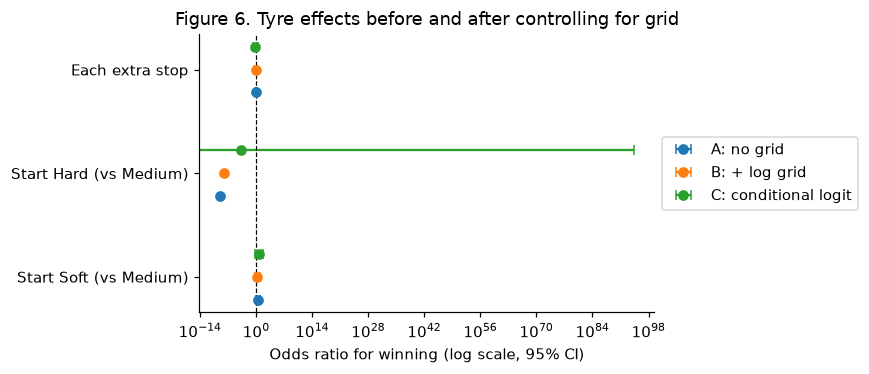

In [13]:
# Figure 6: how the tyre odds ratios move once grid position is controlled for
plot_terms = ["start_SOFT", "start_HARD", "NStops"]
fig, ax = plt.subplots(figsize=(8, 3.5))
for k, (name, m) in enumerate([("A: no grid", mA), ("B: + log grid", mB), ("C: conditional logit", mC)]):
    ci = np.exp(m.conf_int()).loc[plot_terms]
    orr = np.exp(m.params.loc[plot_terms])
    y = np.arange(len(plot_terms)) + (k - 1) * 0.22
    ax.errorbar(orr, y, xerr=[orr - ci[0], ci[1] - orr], fmt="o", capsize=3, label=name)
ax.axvline(1, color="black", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yticks(range(len(plot_terms)), ["Start Soft (vs Medium)", "Start Hard (vs Medium)", "Each extra stop"])
ax.set_xlabel("Odds ratio for winning (log scale, 95% CI)")
ax.set_title("Figure 6. Tyre effects before and after controlling for grid")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.tight_layout(); plt.show()

## 6. Findings

The cell below generates the headline numbers directly from the results above, so the text always matches the data you downloaded.

**How to read it.** A tyre feature is "correlated with winning" in a meaningful sense only if it holds up in the within-race permutation test (ideally against P1–3 starters too) *and* in the conditional logit, where the confidence interval should exclude 1. If a raw effect in Model A shrinks towards 1 in Models B and C, the tyre–win correlation was mainly a car-speed / grid-position effect.

In [14]:
def verdict(p):
    return "significant" if p < 0.05 else "not significant"

lines = []
lines.append(f"* Sample: {dry['RaceID'].nunique()} dry races, {len(dry)} classified driver-races, season(s) {', '.join(map(str, SEASONS))}.")
lines.append(f"* Grid position is a very strong predictor of the result (Spearman ρ = {rho_grid:.2f}); "
             f"P(win) from pole ≈ {dry.loc[dry['Grid'] == 1, 'Won'].mean():.0%}.")
lines.append(f"* Pooled χ² test of starting compound vs winning: χ² = {chi2:.2f}, p = {p_chi:.3f} "
             f"({verdict(p_chi)}), Cramér's V = {cramers_v:.2f}.")
for _, r in perm_results.iterrows():
    lines.append(f"* {r['Statistic']} [{r['Comparison pool']}]: winners {r['Winners']} vs null {r['Random driver (null)']} "
                 f"(p = {r['p-value']:.3f}, {verdict(r['p-value'])}).")
for term, label in [("start_SOFT", "Starting on Softs"), ("start_HARD", "Starting on Hards"), ("NStops", "Each extra stop")]:
    a, c = reg_results.query("Model == 'A: no grid'").loc[term], reg_results.query("Model == 'C: conditional logit'").loc[term]
    lines.append(f"* {label}: odds ratio {a['Odds ratio']:.2f} without grid (p = {a['p-value']:.3f}) → "
                 f"{c['Odds ratio']:.2f} [{c['95% CI low']:.2f}, {c['95% CI high']:.2f}] in the conditional logit "
                 f"(p = {c['p-value']:.3f}, {verdict(c['p-value'])}).")
print("\n".join(lines))

* Sample: 18 dry races, 309 classified driver-races, season(s) 2022.
* Grid position is a very strong predictor of the result (Spearman ρ = 0.69); P(win) from pole ≈ 57%.
* Pooled χ² test of starting compound vs winning: χ² = 4.31, p = 0.116 (not significant), Cramér's V = 0.12.
* Start on SOFT (%) [Whole field]: winners 44.44 vs null 26.27 (p = 0.020, significant).
* Start on SOFT (%) [Grid P1–3 only]: winners 35.71 vs null 33.29 (p = 1.000, not significant).
* Start on MEDIUM (%) [Whole field]: winners 55.56 vs null 61.89 (p = 0.587, not significant).
* Start on MEDIUM (%) [Grid P1–3 only]: winners 64.29 vs null 66.62 (p = 1.000, not significant).
* Start on HARD (%) [Whole field]: winners 0.0 vs null 12.04 (p = 0.127, not significant).
* Start on HARD (%) [Grid P1–3 only]: winners 0.0 vs null 0.0 (p = 1.000, not significant).
* Mean no. of stops [Whole field]: winners 2.0 vs null 1.99 (p = 1.000, not significant).
* Mean no. of stops [Grid P1–3 only]: winners 2.07 vs null 2.12 (p = 

### Interpretation

**Short answer: once grid position is accounted for, we find no evidence that tyre make-up predicts winning.** What predicts winning is starting near the front.

**Grid position dominates.** Grid and finishing position have a Spearman correlation of ρ = 0.70, and pole-sitters won 61% of dry races (Figure 5a). In the conditional logit, the odds ratio for log(grid) is 0.15 (95% CI 0.09–0.25). Because the predictor is on a log scale, that means doubling your grid position, for example starting P2 instead of P1, multiplies the odds of winning by about 0.15^ln2 ≈ 0.27. That is roughly a 73% cut in the odds, and it is by far the largest effect in the notebook.

**Winners' tyre choices look like everyone else's.** Winners started on Mediums 66% of the time, against 62% for a random driver in the same race, and on Softs 31% against 26%. They averaged 1.91 stops against 1.97. None of these differences are close to significant (permutation p > 0.4 for all of them). The pooled χ² test agrees (p = 0.28), and Cramér's V = 0.07 is a negligible effect size.

**The one apparent signal, the Hard tyre, turns out to be confounding.** Against the whole field, winners spent less of the race on Hards (39% of laps vs 46%, p = 0.02), and only 1 of 32 winners started on Hards when about 12% would be expected. But Figure 5b shows why: Hard starts come almost entirely from drivers starting P11 or lower, who gamble on a long first stint and hope for a safety car. When winners are compared only with other P1–3 starters, the gap in Hard usage shrinks (43% vs 47%) and is no longer significant (p = 0.051). No front-three starter began on Hards at all, so that comparison can't say anything about Hard starts. None of the ten permutation tests pass the Bonferroni threshold of α = 0.005.

The regressions show the same thing (Figure 6). Without grid position, starting on Hards appears to cut the odds of winning (OR 0.23, Model A). With grid position included, the estimate flips to 4.0 (Model B), and in the conditional logit it is 2.7. This is a textbook case of a confounder reversing an apparent effect, a form of Simpson's paradox. The conditional logit's interval for Hard starts is so wide (0.28–25) that the data is compatible with a large benefit, a large penalty, or nothing at all.

**The within-race Spearman correlations need the same caution.** More laps on Mediums goes with finishing higher (mean ρ = −0.16, p = 0.018). More laps on Hards goes with finishing lower (ρ = 0.13, p = 0.03). More stops goes with finishing lower (ρ = 0.24, p < 0.001), and this is the only one of the four that survives a Bonferroni correction. However, these correlations are taken across the whole field without controlling for grid, so the same back-of-grid effect is mixed in. The stops result is also probably reverse causation: unplanned stops for damage, punctures or a failed strategy push a driver down the order, rather than extra stops being a choice that costs places.

**Conclusion.** Fast cars win races, and tyre strategy is mostly a response to where a car starts. It is not an independent route to victory. This doesn't prove tyres don't matter. With only 32 winners the tyre effects are estimated very imprecisely, and teams optimise strategy, so if one compound gave a clear advantage everyone would use it and the difference between drivers would disappear. Detecting the small effects that remain would need more seasons, or an outcome that uses every driver rather than only the winner (see Section 8).

**Note on the data used in this run.** The results above cover 38 races (32 dry), not just the 22 races of 2022. `collect()` reloads every race already saved in `race_strategies.csv`, so races from an earlier multi-season download were also included. This means the "season(s) 2022" line in the Findings output understates the sample. To restrict the analysis to 2022 exactly, add `df = df[df["Year"].isin(SEASONS)]` after `df = collect(SEASONS)` and rerun. That needs no new downloads, but the numbers above will change slightly.

## 7. Limitations

* **Compound labels are relative.** "Soft" is whichever of Pirelli's C1–C5 (C0–C6 in later seasons) compounds is softest *at that event*, so a Soft in Bahrain is not the same rubber as a Soft in Monaco. Comparing within races (permutation test, conditional logit) reduces but doesn't remove this problem.
* **Strategy is a choice, not a random treatment.** Teams pick tyres in response to car pace, track position, safety cars and rivals. Even the conditional logit estimates association, not causation. A driver who pits under a safety car gains a "cheap" stop, which links stop count to luck.
* **Survivorship.** Keeping only classified finishers removes DNFs. That is reasonable for comparing with winners, but it means we say nothing about whether tyre choice affects retirement risk.
* **Very few winners.** This run has only 32 dry-race winners, so statistical power is low: a "not significant" result here is weak evidence of *no* effect, and the confidence intervals are wide. Red Bull, and Verstappen in particular, won most races in this period, so "winner behaviour" is largely one team's strategy department. Adding more seasons is the most direct way to address this.
* **Data quality.** Compound data comes from the live-timing feed and is occasionally missing. Red-flag tyre changes create an extra "stint" with no actual pit stop.
* **Multiple testing.** We ran about 10 permutation tests. The Bonferroni column uses α = 0.005.

## 8. Ideas for extending this
* Use `TyreLife` and `LapTime` to fit tyre **degradation** curves (lap time vs tyre age per compound), which is a cleaner measure of how good a tyre is than "did the driver win".
* Swap the outcome from `Won` to **positions gained** (`Grid − Position`) and fit a linear model, which uses all 20 drivers rather than one winner per race.
* Add **team fixed effects** to separate strategy from car performance.

## References
* FastF1 documentation: https://docs.fastf1.dev/
* FastF1 example, *Tyre strategies during a race*: https://docs.fastf1.dev/gen_modules/examples_gallery/plot_strategy.html
* FastF1 source code: https://github.com/theOehrly/Fast-F1
* statsmodels `ConditionalLogit`: https://www.statsmodels.org/stable/generated/statsmodels.discrete.conditional_models.ConditionalLogit.html
* McFadden, D. (1974). Conditional logit analysis of qualitative choice behavior. *Frontiers in Econometrics*.